In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE


df = pd.read_csv("D:/Đại học/1. Nghiên cứu Khoa học/Dataset/Folder_Dataset/P2P_Dataset.csv")
boolean_cols = df.select_dtypes(include=['bool']).columns
df[boolean_cols] = df[boolean_cols].astype(int)


In [ ]:
df = df.drop(columns=["badloan", "funded_amnt", "sub_grade", "pub_rec", "num_tl_30dpd"])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[LightGBM] [Info] Number of positive: 988077, number of negative: 1976154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.199099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3624
[LightGBM] [Info] Number of data points in the train set: 2964231, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
Biến: acc_now_delinq, Tầm quan trọng: 0.00000
Biến: acc_open_past_24mths, Tầm quan trọng: 45.00000
Biến: annual_inc, Tầm quan trọng: 60.00000
Biến: chargeoff_within_12_mths, Tầm quan trọng: 0.00000
Biến: collections_12_mths_ex_med, Tầm quan trọng: 0.00000
Biến: delinq_2yrs, Tầm quan trọng: 21.00000
Biến: delinq_amnt, Tầm quan trọng: 0.00000
Biến: dti, Tầm quan trọng: 40.00000
Biến: earnings, Tầm quan trọng: 601.00000
Biến: emp_length

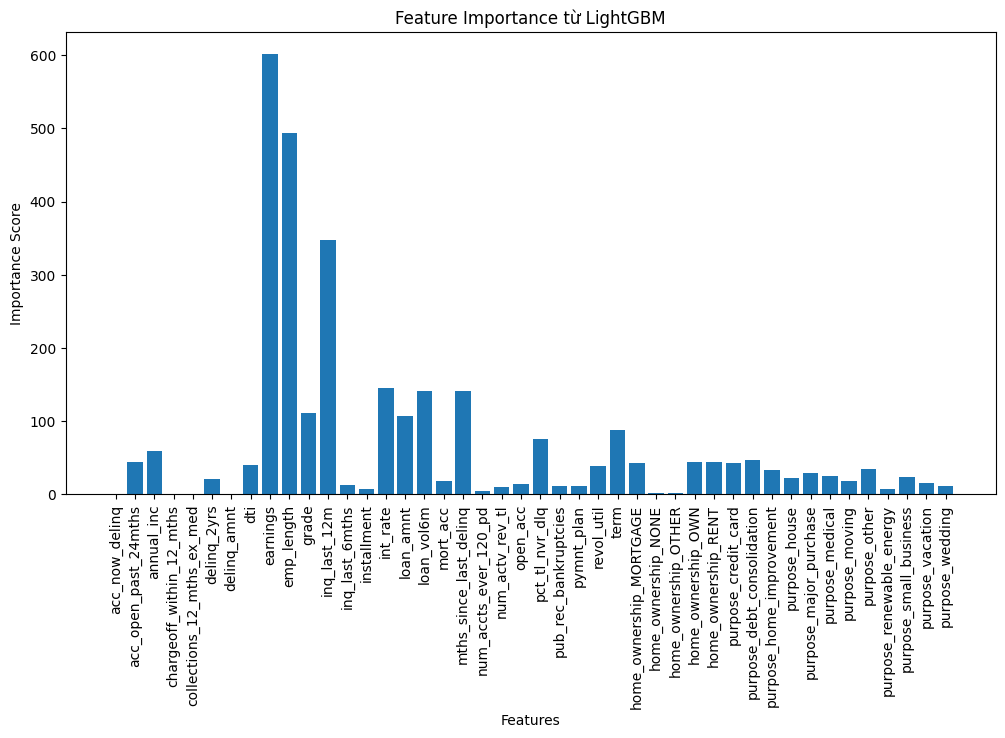

In [ ]:
# 🎯 Chia X, y
X = df.drop(columns=["default_binary"], errors="ignore")
y = df["default_binary"]

# 🔀 Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)

# ⚖️ Cân bằng dữ liệu bằng SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 🚀 Huấn luyện mô hình LightGBM cơ bản
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train_resampled, y_train_resampled)

# 🔍 Lấy độ quan trọng của từng biến
importance_lgb = lgb_model.feature_importances_

# 📊 Hiển thị tầm quan trọng của biến
for i, v in enumerate(importance_lgb):
    print(f'Biến: {X_train.columns[i]}, Tầm quan trọng: {v:.5f}')

# 🎨 Vẽ biểu đồ Feature Importance
plt.figure(figsize=(12, 6))
plt.bar([x for x in range(len(importance_lgb))], importance_lgb)
plt.xticks(range(len(importance_lgb)), X_train.columns, rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance từ LightGBM")
plt.show()


In [ ]:
# 🎯 Chỉ chọn các biến có tầm quan trọng > 10
important_features_lgb = X_train.columns[importance_lgb > 20]

# 🔄 Cập nhật X_train và X_test chỉ với các biến quan trọng3
X_train_selected = X_train_resampled[important_features_lgb]
X_test_selected = X_test[important_features_lgb]

# 🔄 Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV

# 🛠 Định nghĩa tập siêu tham số (RandomizedSearchCV sẽ chọn ngẫu nhiên)
param_dist = {
    'num_leaves': [20, 31, 50, 80],  # Số lá trong mỗi cây quyết định
    'learning_rate': [0.01, 0.05, 0.1],  # Tốc độ học
    'n_estimators': [50, 100, 200],  # Số lượng cây quyết định
    'max_depth': [-1, 10, 20],  # Độ sâu tối đa (-1 nghĩa là không giới hạn)
    'boosting_type': ['gbdt', 'dart'],  # Kiểu boosting
    'subsample': [0.7, 0.8, 1.0],  # Lấy mẫu ngẫu nhiên
    'colsample_bytree': [0.7, 0.8, 1.0]  # Lấy mẫu cột
}

# 🚀 Randomized Search (n_iter=20 để tăng tốc)
random_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,  # Chỉ thử 20 tổ hợp
    scoring="roc_auc",
    cv=3,  # Giảm số lần cross-validation để chạy nhanh hơn
    n_jobs=-1,  # Chạy song song
    random_state=42
)

# 🔥 Huấn luyện mô hình và tìm siêu tham số tối ưu
random_search.fit(X_train_selected_scaled, y_train_resampled)

# 📌 Lấy siêu tham số tốt nhất
best_params = random_search.best_params_
print("\n🔥 Best Hyperparameters for LightGBM:")
print(best_params)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 988077, number of negative: 1976154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.160583 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2929
[LightGBM] [Info] Number of data points in the train set: 2964231, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147

🔥 Best Hyperparameters for LightGBM:
{'subsample': 0.8, 'num_leaves': 50, 'n_estimators': 100, 'max_depth': 20, 'learning_rate': 0.1, 'colsample_bytree': 0.7, 'boosting_type': 'gbdt'}


In [ ]:
# 🏆 Huấn luyện lại mô hình với siêu tham số tốt nhất
best_lgbm_model = lgb.LGBMClassifier(**best_params, random_state=42)
best_lgbm_model.fit(X_train_selected_scaled, y_train_resampled)

# 📊 Dự đoán trên tập kiểm tra
y_pred_lgbm = best_lgbm_model.predict(X_test_selected_scaled)
y_prob_lgbm = best_lgbm_model.predict_proba(X_test_selected_scaled)[:, 1]

# 📈 Đánh giá mô hình
accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
roc_auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)
conf_matrix_lgbm = confusion_matrix(y_test, y_pred_lgbm)
report_lgbm = classification_report(y_test, y_pred_lgbm)

# 📝 In kết quả
print("\n LightGBM Model Evaluation (Optimized with RandomizedSearchCV)")
print(f" Accuracy: {accuracy_lgbm:.4f}")
print(f" AUC-ROC: {roc_auc_lgbm:.4f}")
print(f" Classification Report:\n{report_lgbm}")
print(f" Confusion Matrix:\n{conf_matrix_lgbm}")

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 988077, number of negative: 1976154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.178005 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2929
[LightGBM] [Info] Number of data points in the train set: 2964231, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147


c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



 LightGBM Model Evaluation (Optimized with RandomizedSearchCV)
 Accuracy: 0.9129
 AUC-ROC: 0.7975
 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95    494039
           1       0.46      0.05      0.09     46647

    accuracy                           0.91    540686
   macro avg       0.69      0.52      0.52    540686
weighted avg       0.88      0.91      0.88    540686

 Confusion Matrix:
[[491251   2788]
 [ 44297   2350]]
